In [20]:
import arviz as az
import pandas as pd
from anthropmass.bambi_model_module import *
az.style.use("arviz-darkgrid")

In [21]:
def summary(fitted):
    return az.summary(fitted)

In [22]:
def graph(model):
    return model.graph()

In [23]:
def plot_prior_predictive(model):
    prior_pred = model.prior_predictive(draws=1000)
    az.plot_ppc(prior_pred, group='prior')

In [24]:
def plot_posterior_predictive(model, fitted):
    model.predict(fitted, kind='response')
    az.plot_ppc(fitted)

In [25]:
def plot_forest(fitted, variables:list):
    az.plot_forest(fitted, var_names=variables)

In [26]:
def plot_hdi_priors(model):
    model.plot_priors()

In [27]:
def plot_hdi_posteriors(fitted, variables:list):
    az.plot_posterior(fitted, var_names=variables)

In [28]:
def plot_trace(fitted, variables:list):
    az.plot_trace(fitted, compact=False, var_names=variables)

In [29]:
train=pd.read_csv('../data/processed/ANSURIIminusmeanstrain.csv')

In [30]:
model0, fitted0 = make_model('neckcircumference', train, '0 + C(Gender) + Component + weightkg + stature')

Initializing NUTS using adapt_diag...
Sequential sampling (4 chains in 1 job)
NUTS: [sigma, C(Gender), Component, weightkg, stature]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 24 seconds.


In [31]:
summary(fitted0)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
sigma,14.090,0.143,13.832,14.375,0.001,0.002,11391.0,5995.0,1.0
C(Gender)[0],342.824,0.493,341.891,343.722,0.005,0.006,9291.0,6150.0,1.0
C(Gender)[1],392.018,0.355,391.356,392.689,0.004,0.004,7549.0,5934.0,1.0
Component[Army Reserve],0.593,1.103,-1.528,2.620,0.011,0.012,9922.0,6664.0,1.0
Component[Regular Army],-0.968,0.413,-1.742,-0.185,0.005,0.004,7394.0,6110.0,1.0
weightkg,1.614,0.017,1.581,1.645,0.000,0.000,10271.0,6064.0,1.0
stature,-0.077,0.003,-0.083,-0.070,0.000,0.000,8796.0,6091.0,1.0


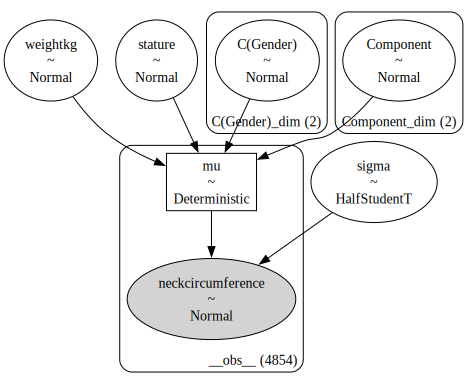

In [32]:
graph(model0)

Sampling: [C(Gender), Component, neckcircumference, sigma, stature, weightkg]


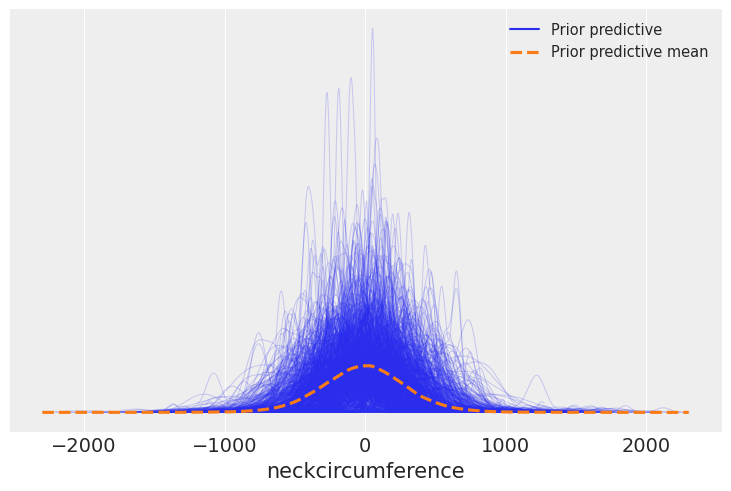

In [33]:
plot_prior_predictive(model0)

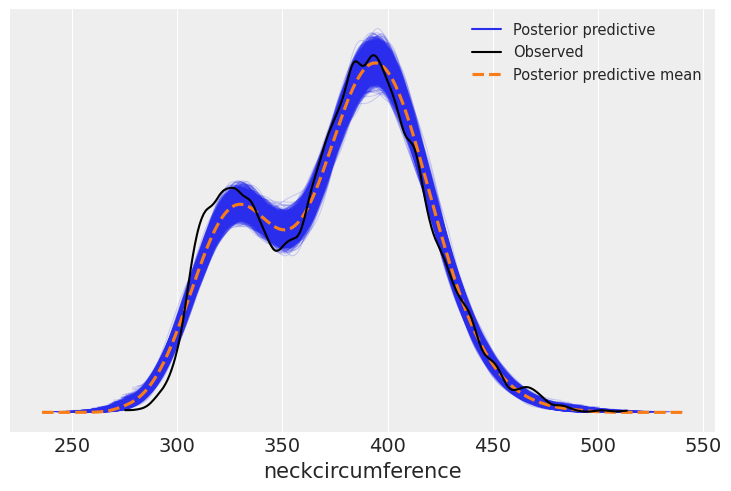

In [34]:
plot_posterior_predictive(model0, fitted0)

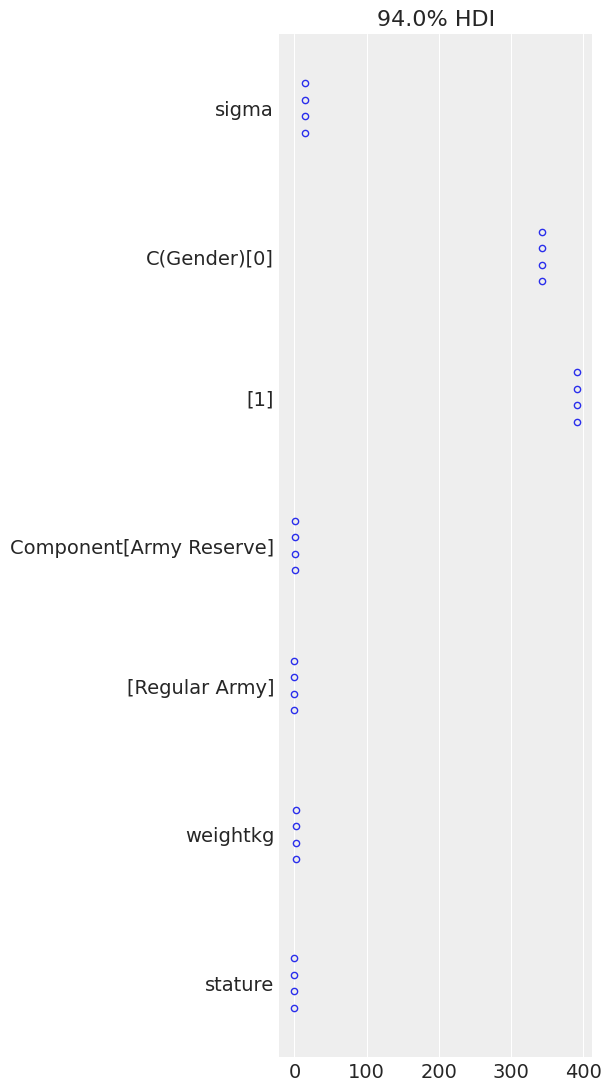

In [35]:
plot_forest(fitted0, variables= ["sigma", "C(Gender)", "Component", "weightkg", "stature"])

Sampling: [C(Gender), Component, sigma, stature, weightkg]


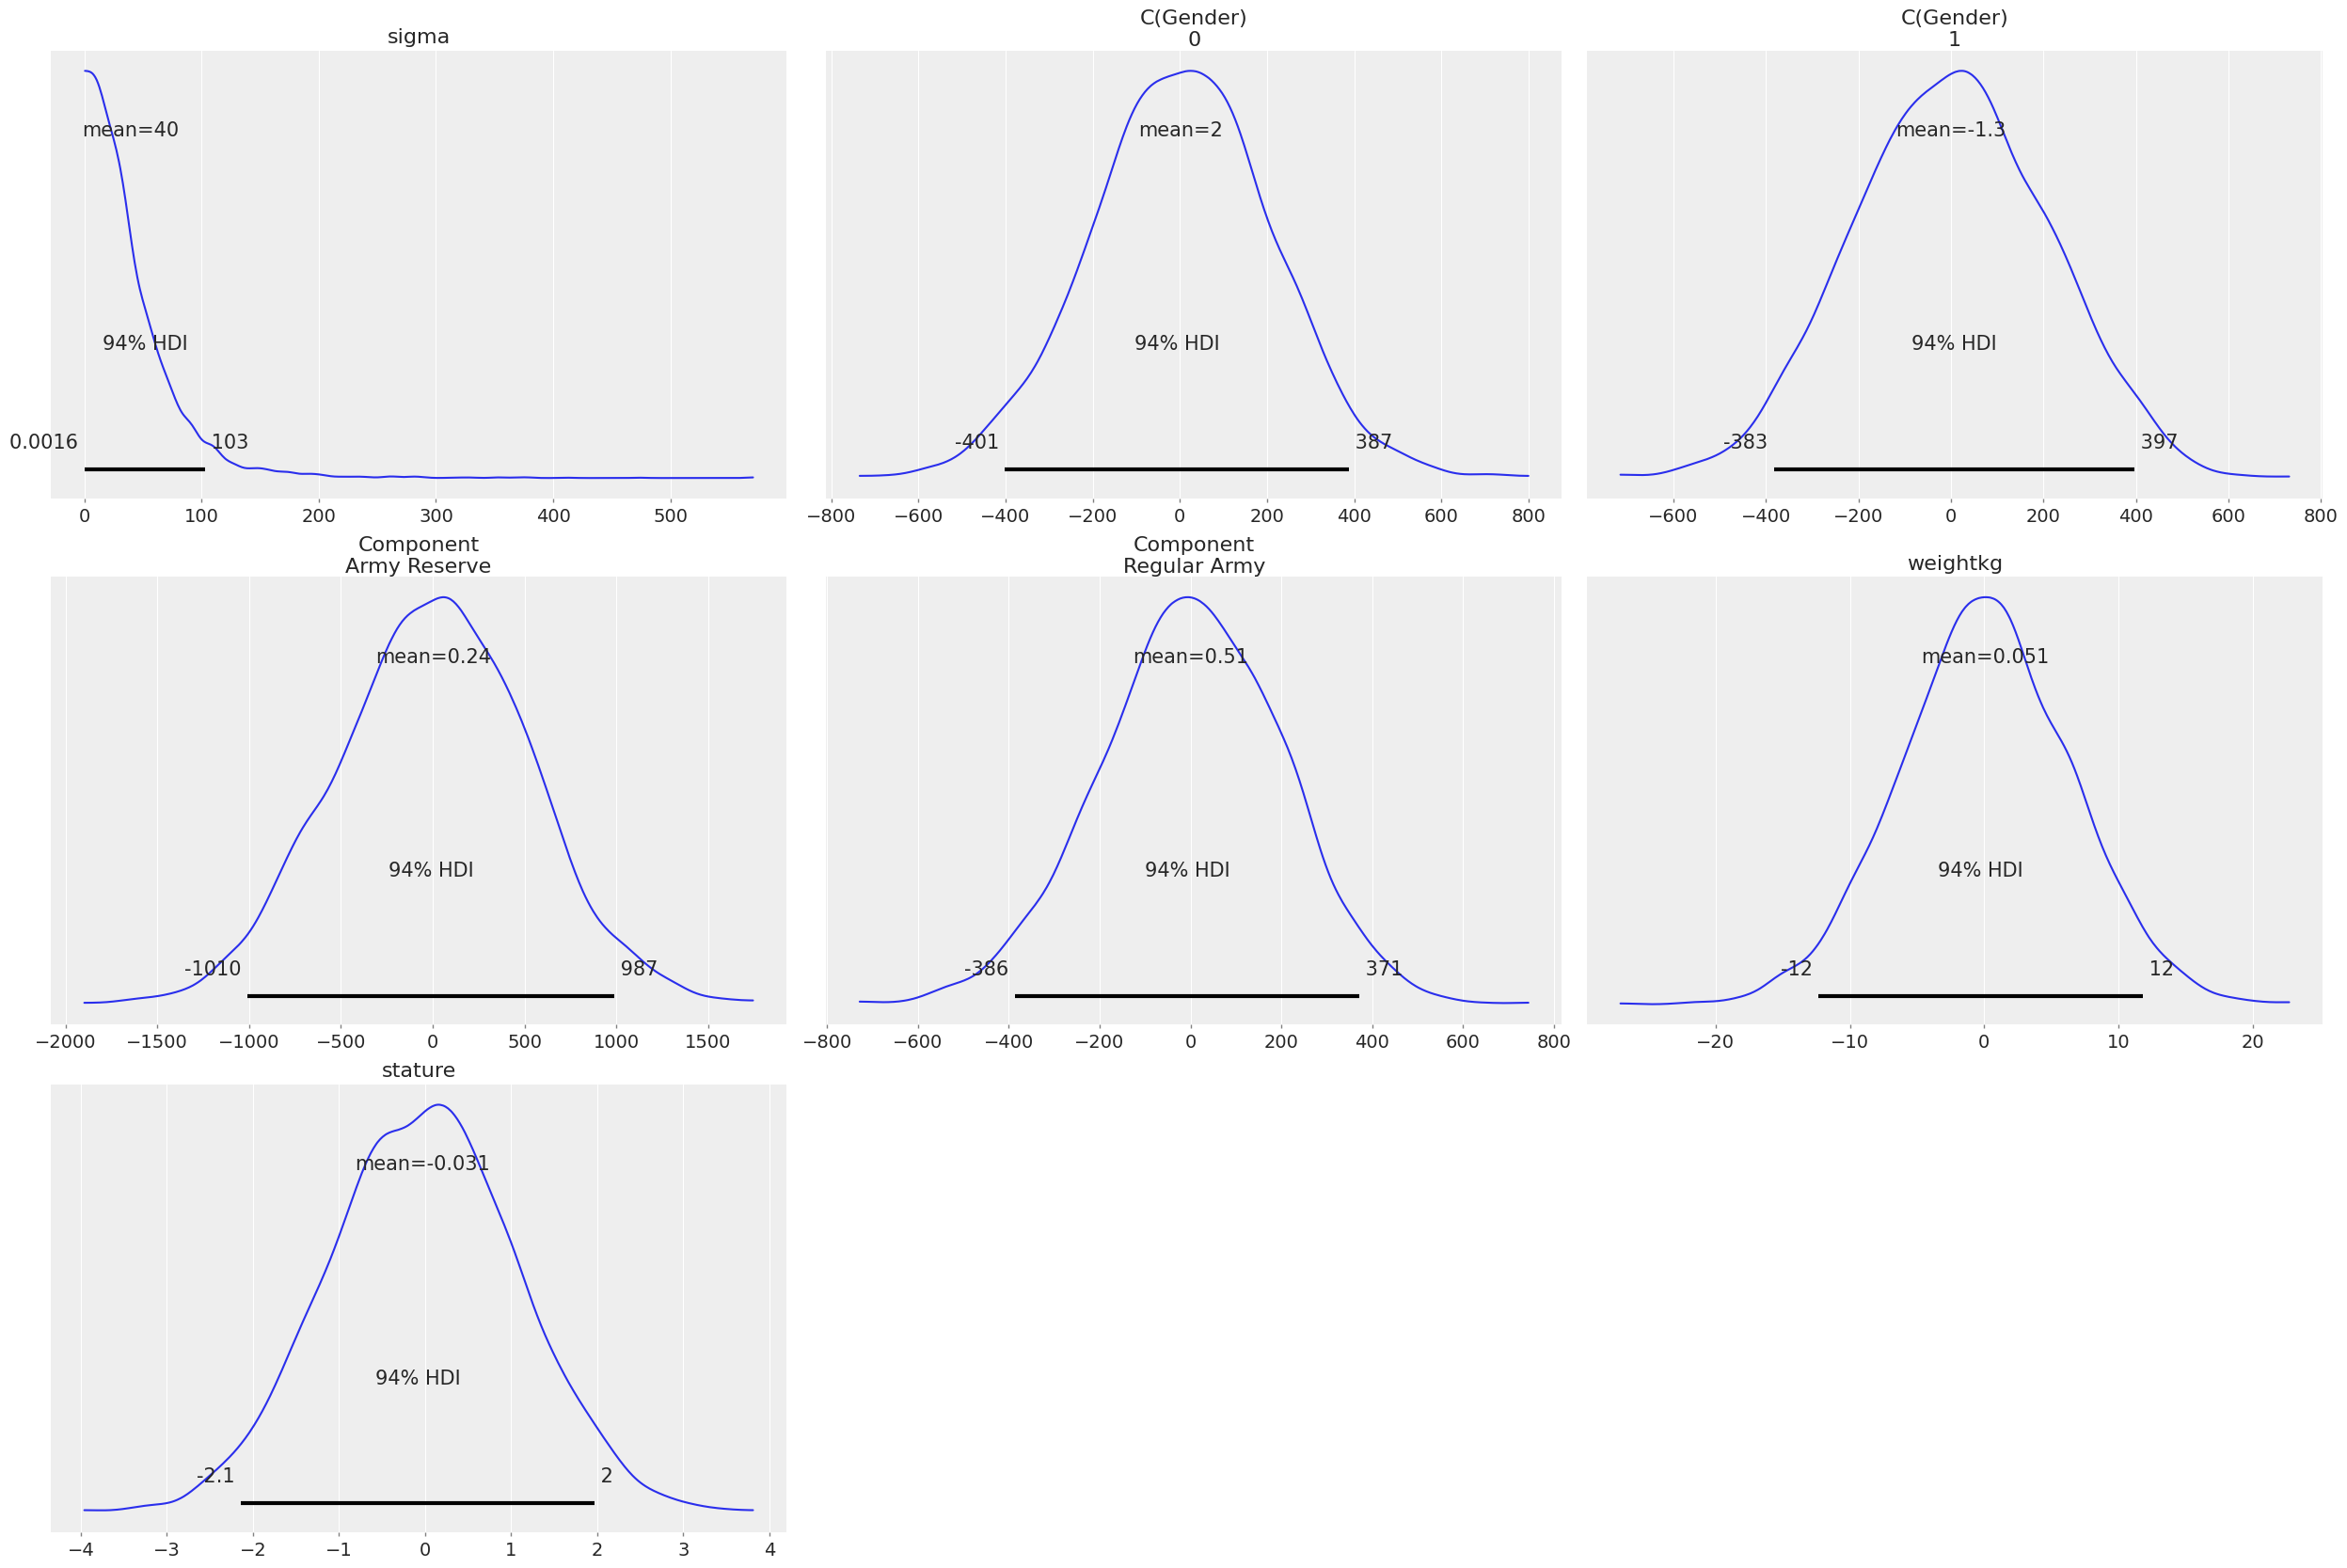

In [36]:
plot_hdi_priors(model0)

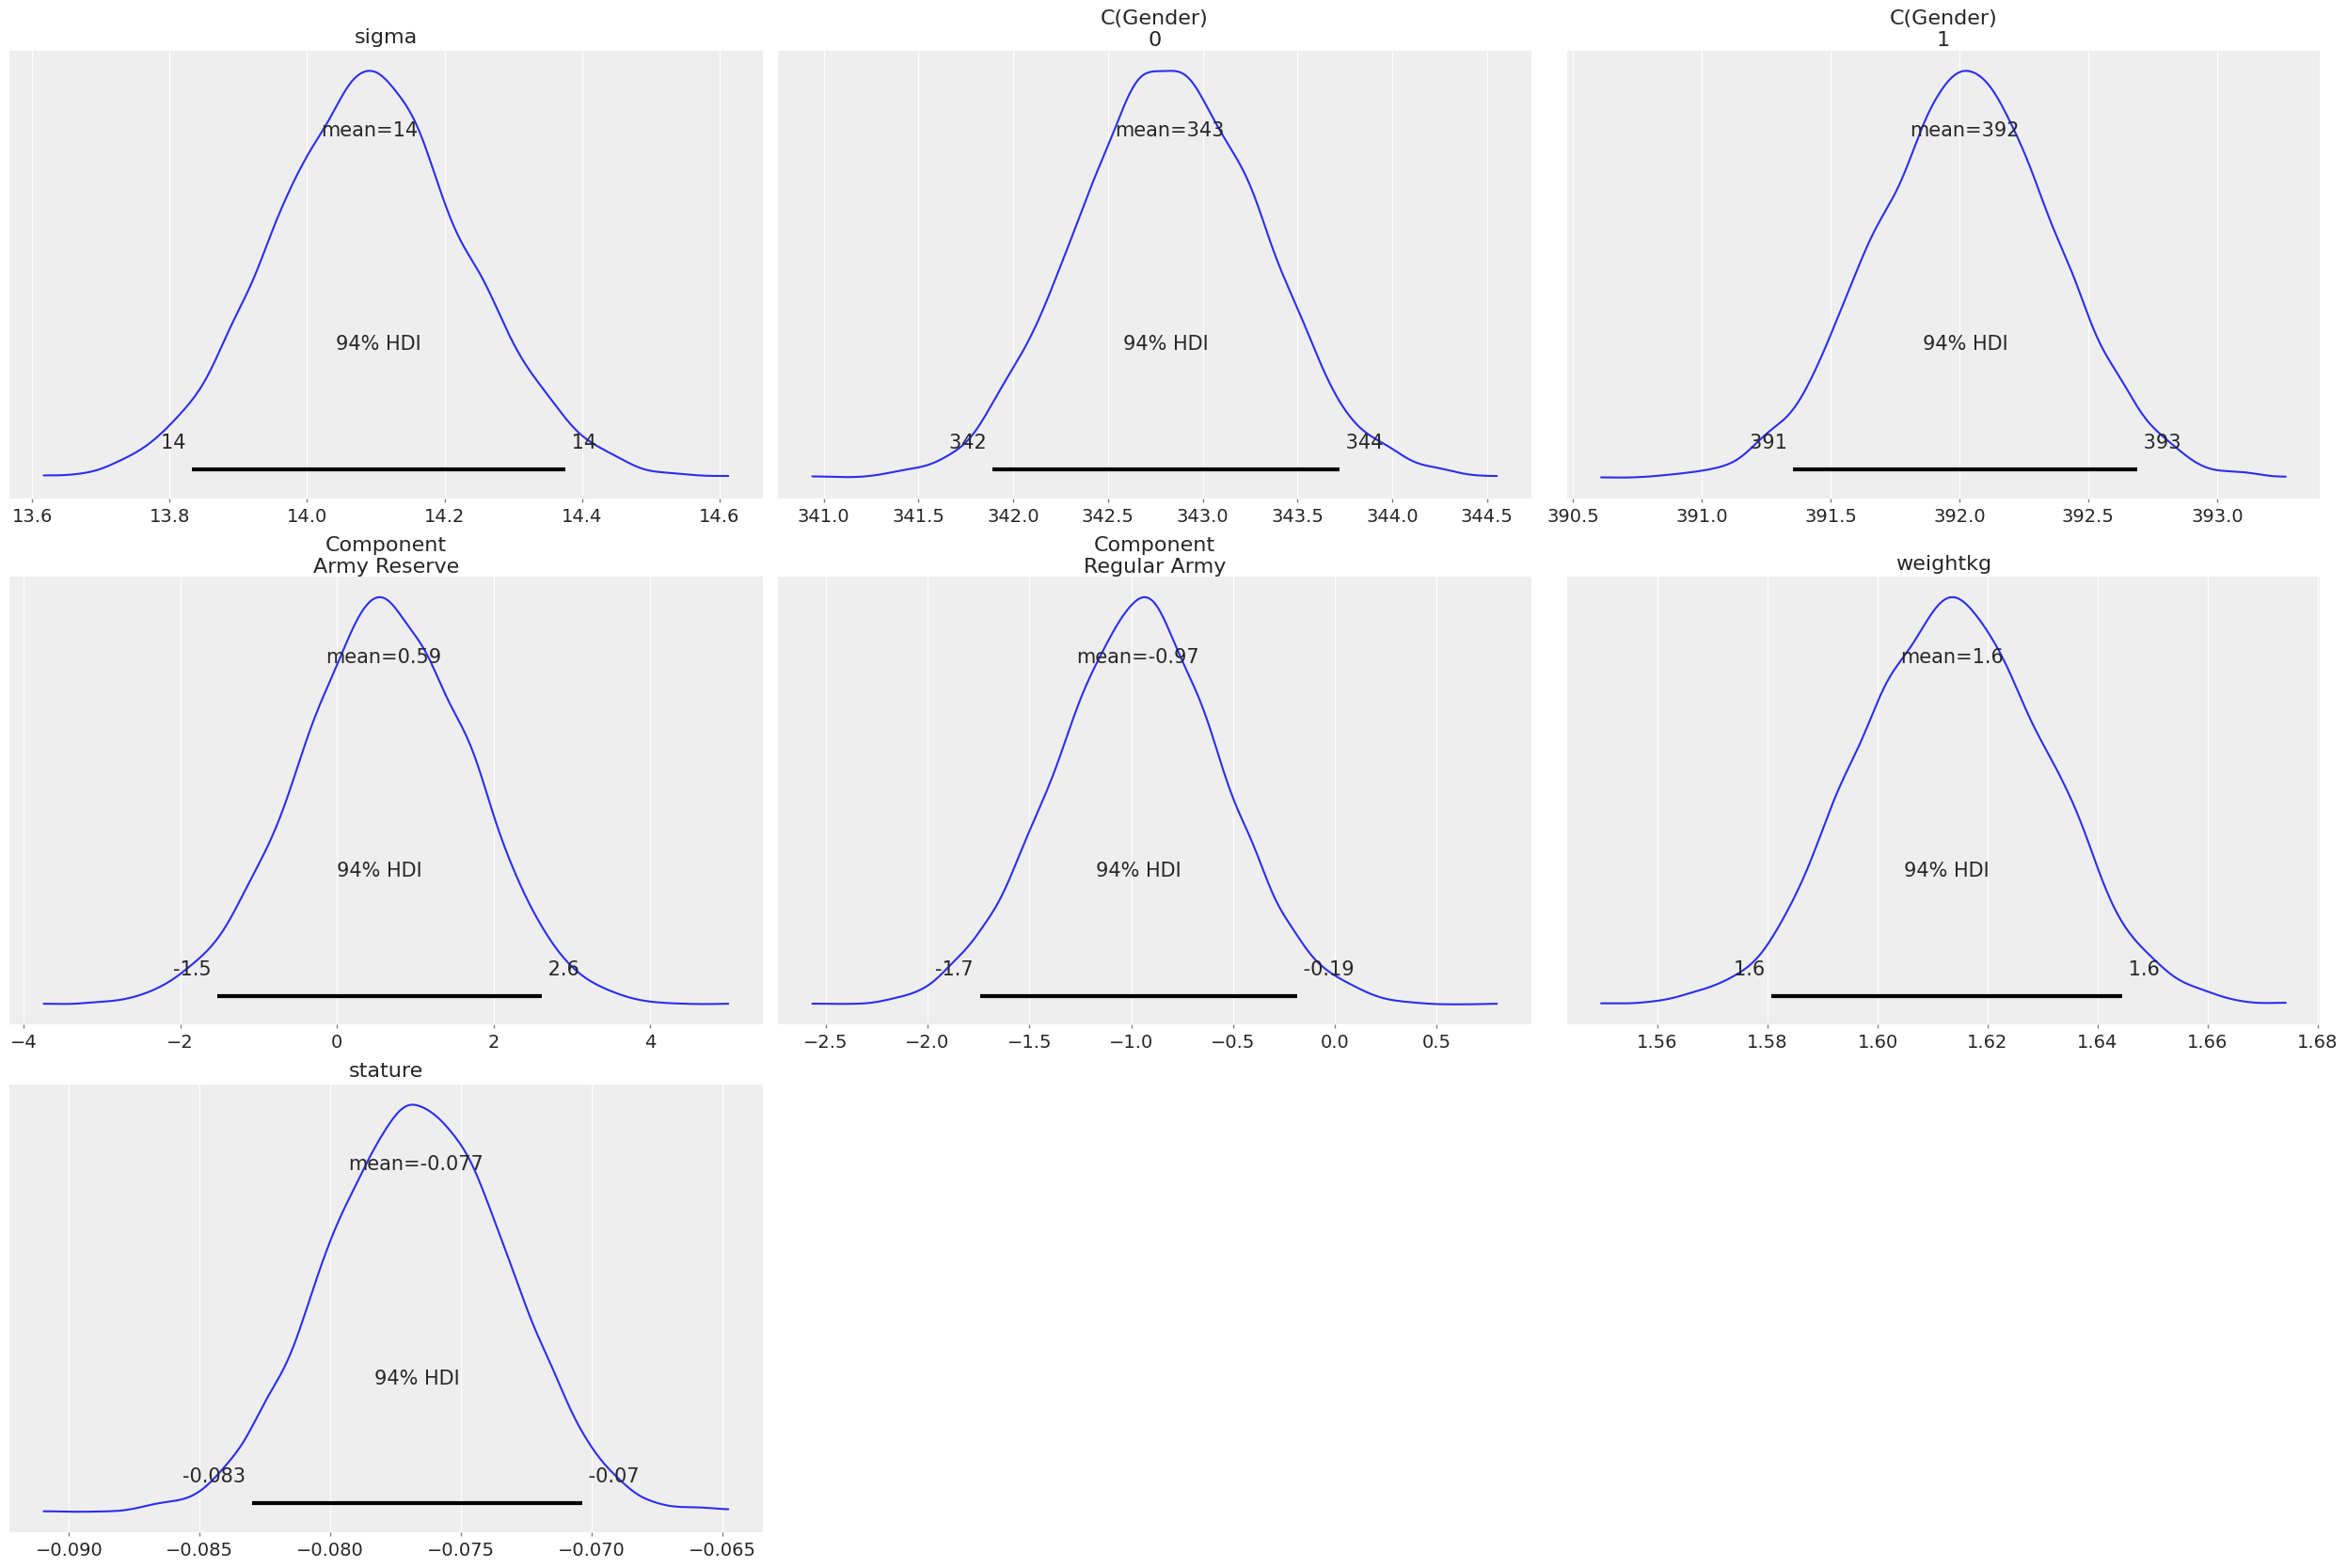

In [37]:
plot_hdi_posteriors(fitted0, variables=  ["sigma", "C(Gender)", "Component", "weightkg", "stature"])

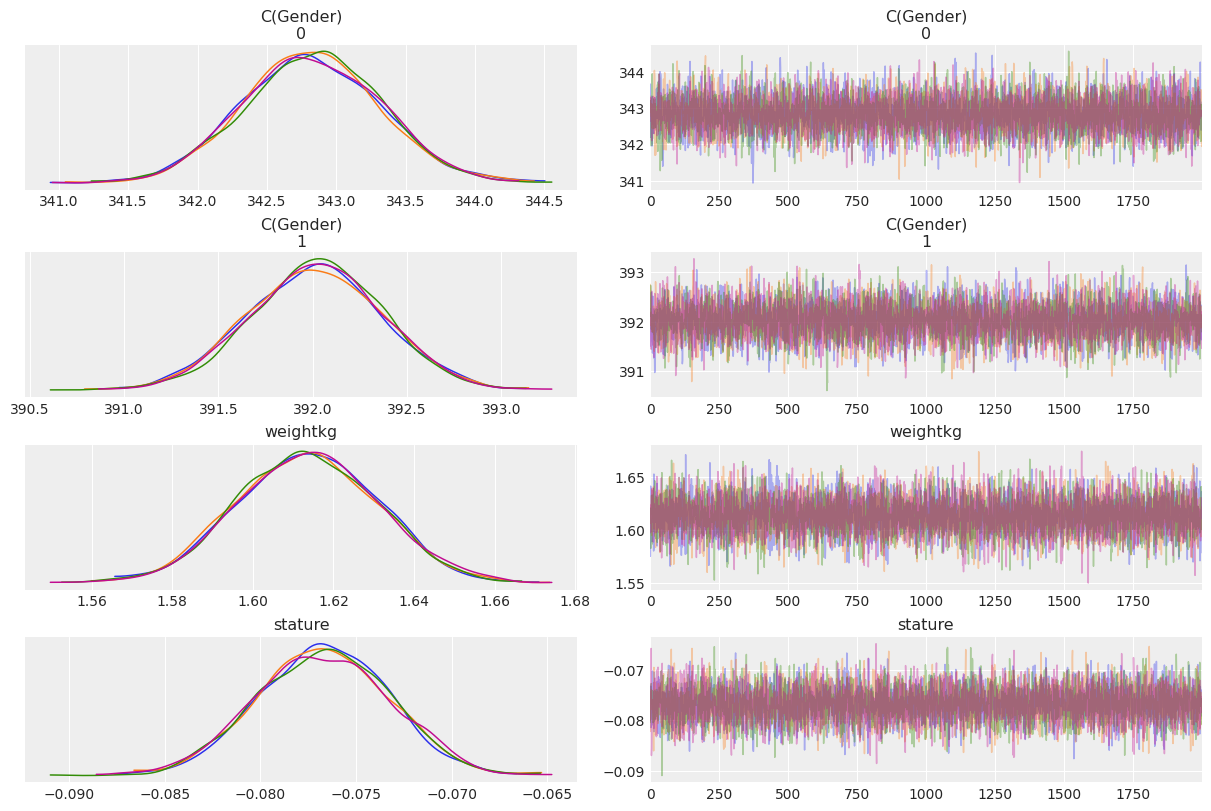

In [39]:
plot_trace(fitted0, variables= ["C(Gender)", "weightkg", "stature"])